# Vodafone Music Subscription Prediction

## Sprint 1 - Data Cleaning & Preparation

**Goal of this notebook:**

Prepare a clean, model-ready dataset by handling missing values,
removing low-quality features, and documenting every cleaning decision.

**Notebook outline:**
1. Cleaning Strategy
2. Load Data
3. Feature Dictionary Mapping
4. Dictionary Coverage Validation
5. Missing Values Audit
6. Missingness as Signal (Indicators)
7. Group-Based Imputation
8. Imputation Report
9. Low-Information Features Removal
10. Duplicate Check
11. Final Validation & Save

### 1. Cleaning Strategy

Based on the EDA findings from `01_data_understanding.ipynb`:

| Issue | Scale | Action |
|---|---|---|
| High dimensionality | 461 features | Remove zero-info columns |
| Structural missingness | 449 columns have NaNs | Semantic imputation (not one global rule) |
| Class imbalance | 7.6% positive | Document; address in modeling stage |
| Constant columns | 19 identified | Drop |
| Quasi-constant columns | TBD | Drop (>99.9% same value) |

**Cleaning steps:**
1. Remove non-informative technical column (`id`)
2. Parse feature dictionary → assign each feature to a semantic group
3. Create missingness indicators (`__was_missing`) for highly sparse features → treat as feature engineering signal
4. Apply group-based imputation: `count_*`/`vol_*`/`*flag*` → 0; continuous → median
5. Remove constant and quasi-constant columns
6. Check for duplicate rows
7. Validate: 0 NaNs remain, save cleaned dataset

### 2. Load Data

We load the raw training dataset and remove technical identifiers that should not be used for learning.

In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/music.csv"
DICT_PATH = "../data/raw/Feature_dictionary.xlsx"

df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)

# Drop technical identifier
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("After dropping id:", df.shape)

Original shape: (70000, 461)
After dropping id: (70000, 460)


### 3. Feature Dictionary Mapping (Feature → Group)

We build a mapping from each feature name to its semantic group (13 groups) using `Feature_dictionary.xlsx`.
This allows us to apply different imputation rules depending on feature meaning.

In [2]:
fd = pd.read_excel(DICT_PATH)

feature_to_group = {}
current_group = None

for _, row in fd.iterrows():
    name = row["Feature Name"]
    desc = row["Feature Description"]

    if pd.isna(name):
        continue

    name = str(name).strip()

    if pd.isna(desc):
        current_group = name
        continue

    if current_group:
        feature_to_group[name.lower()] = current_group

print("Mapped features from dictionary:", len(feature_to_group))

def strip_m_suffix(col: str) -> str:
    col = col.lower()
    return col.replace("_m1", "").replace("_m2", "").replace("_m3", "")


Mapped features from dictionary: 221


#### Mapping Result Summary

The feature dictionary mapping successfully identified **221 base features** and assigned them
to one of the **13 semantic groups** defined in `Feature_dictionary.xlsx`.

The `strip_m_suffix()` helper ensures that time-based variants (`_m1`, `_m2`, `_m3`)
inherit the same semantic group as their base feature.

**The 13 semantic groups:**
1. Device Characteristics
2. General Characteristics
3. User Activity Features
4. Features in Dynamics (m1/m2/m3)
5. All Costs
6. Recharg. Statistics
7. Voice Costs
8. Voice Duration
9. Network Actions Stats
10. Other Essential Features
11. SMS from Services
12. Interests Data
13. Previous Campaigns Results

This mapping enables group-aware imputation — a more principled approach than a single global fill rule.

### 4. Dictionary Coverage (Mapped vs Unmapped)

We verify how many columns are covered by the dictionary (direct match or via `_m1/_m2/_m3` suffix stripping).

In [3]:
df_cols = [c for c in df.columns if c != "target"]

direct_mapped = [c for c in df_cols if c in feature_to_group]

mapped_via_suffix = []
unmapped = []

for c in df_cols:
    if c in feature_to_group:
        continue
    base = strip_m_suffix(c)
    if base in feature_to_group:
        mapped_via_suffix.append(c)
    else:
        unmapped.append(c)

print("\n--- Feature Dictionary Coverage ---")
print(f"Total columns (excluding target): {len(df_cols)}")
print(f"Mapped directly: {len(direct_mapped)}")
print(f"Mapped via _m1/_m2/_m3 base name: {len(mapped_via_suffix)}")
print(f"Unmapped (fallback rules will apply): {len(unmapped)}")

if unmapped:
    print("Unmapped examples:", unmapped[:20])


--- Feature Dictionary Coverage ---
Total columns (excluding target): 459
Mapped directly: 102
Mapped via _m1/_m2/_m3 base name: 357
Unmapped (fallback rules will apply): 0


#### Coverage Interpretation

All dataset features are successfully mapped to one of the 13 semantic groups.

* 102 features are directly defined in the dictionary.

* 357 dynamic features (`_m1`, `_m2`, `_m3`) correctly inherit their base feature group.

* No unmapped features were detected.

This confirms that semantic grouping is complete and group-based imputation can be applied safely.

### 5. Missing Values Audit

We compute missing ratios and summarize the overall missingness in the dataset.

In [4]:
missing_ratio = df.isna().mean().sort_values(ascending=False)

print("Top-20 missing ratio:")
print(missing_ratio.head(20))

total_missing = int(df.isna().sum().sum())
cols_with_missing = int((df.isna().sum() > 0).sum())

print("\nTotal missing values:", total_missing)
print("Columns with >=1 missing:", cols_with_missing)

Top-20 missing ratio:
count_url_category_13    0.992771
count_url_category_15    0.987029
vol_app_3                0.986643
count_app_3              0.986643
count_url_category_12    0.983129
vol_app_11               0.977329
count_app_11             0.977329
count_app_13             0.973143
vol_app_13               0.973143
count_url_category_1     0.972186
count_gift_type_4        0.969586
rr_gift_type_4           0.969586
count_app_16             0.967171
vol_app_16               0.967171
vol_app_14               0.964086
count_app_14             0.964086
count_url_category_11    0.948486
service_9_flag_m3        0.947871
service_9_flag_m1        0.945414
service_9_flag_m2        0.945157
dtype: float64

Total missing values: 5113163
Columns with >=1 missing: 449


#### Missingness Interpretation

The dataset exhibits a very high level of structural sparsity:

* 449 out of 459 features contain missing values.

* Over 5 million missing entries are present in total.

* The most sparse features (>95% missing) belong primarily to:

  * Interests Data

  * App Usage

  * Campaign Activity

This pattern suggests that missing values are not random noise but reflect absence of user activity.

Therefore, missingness will be treated as meaningful signal rather than purely data quality issue.

### 6. Missingness as Signal (Feature Engineering)

For the most sparse features, the **fact that a value is missing** can itself be informative.
For example, if `service_9_flag` is missing for a subscriber, it likely means they never had that service —
which may correlate with subscription behavior.

We create binary `__was_missing` indicators for the top-20 most sparse features
and check their Pearson correlation with `target`.

> **Design decision:** indicators with meaningful correlation (|r| > 0.02) will be **retained**
> in the final dataset as engineered features. Others will be dropped before saving.

In [5]:
TOP_N = 20

# Clean up any previous run artifacts
df = df.loc[:, ~df.columns.str.endswith('__was_missing')]

top_sparse = [c for c in missing_ratio.head(TOP_N).index.tolist() if c != 'target']

# Create binary missingness indicators
miss_df = df[top_sparse].isna().astype(int)
miss_df.columns = [f'{c}__was_missing' for c in top_sparse]

df = pd.concat([df, miss_df], axis=1).copy()

# Compute correlation with target
miss_corr = df[miss_df.columns.tolist() + ['target']].corr(numeric_only=True)['target'].sort_values(ascending=False)

print('Top missingness indicators correlation with target:')
print(miss_corr.head(10))
print()
print('Bottom missingness indicators correlation with target:')
print(miss_corr.tail(10))

# Keep only indicators with |r| > 0.02 (meaningful signal)
SIGNAL_THRESHOLD = 0.02
keep_indicators = miss_corr[(miss_corr.index != 'target') & (miss_corr.abs() > SIGNAL_THRESHOLD)].index.tolist()
drop_indicators  = [c for c in miss_df.columns if c not in keep_indicators]

df = df.drop(columns=drop_indicators)
print(f'\nMissingness indicators kept (|r| > {SIGNAL_THRESHOLD}): {len(keep_indicators)}')
print(f'Missingness indicators dropped (noise):       {len(drop_indicators)}')
if keep_indicators:
    print('Kept:', keep_indicators)

Top missingness indicators correlation with target:
target                                1.000000
rr_gift_type_4__was_missing           0.028371
count_gift_type_4__was_missing        0.028371
count_url_category_15__was_missing    0.005136
count_url_category_11__was_missing   -0.000714
vol_app_11__was_missing              -0.001023
count_app_11__was_missing            -0.001023
count_url_category_13__was_missing   -0.001072
count_url_category_1__was_missing    -0.003795
vol_app_16__was_missing              -0.005750
Name: target, dtype: float64

Bottom missingness indicators correlation with target:
count_app_13__was_missing            -0.006557
vol_app_13__was_missing              -0.006557
count_url_category_12__was_missing   -0.008203
vol_app_14__was_missing              -0.010046
count_app_14__was_missing            -0.010046
vol_app_3__was_missing               -0.015613
count_app_3__was_missing             -0.015613
service_9_flag_m3__was_missing       -0.096357
service_9_flag_m2

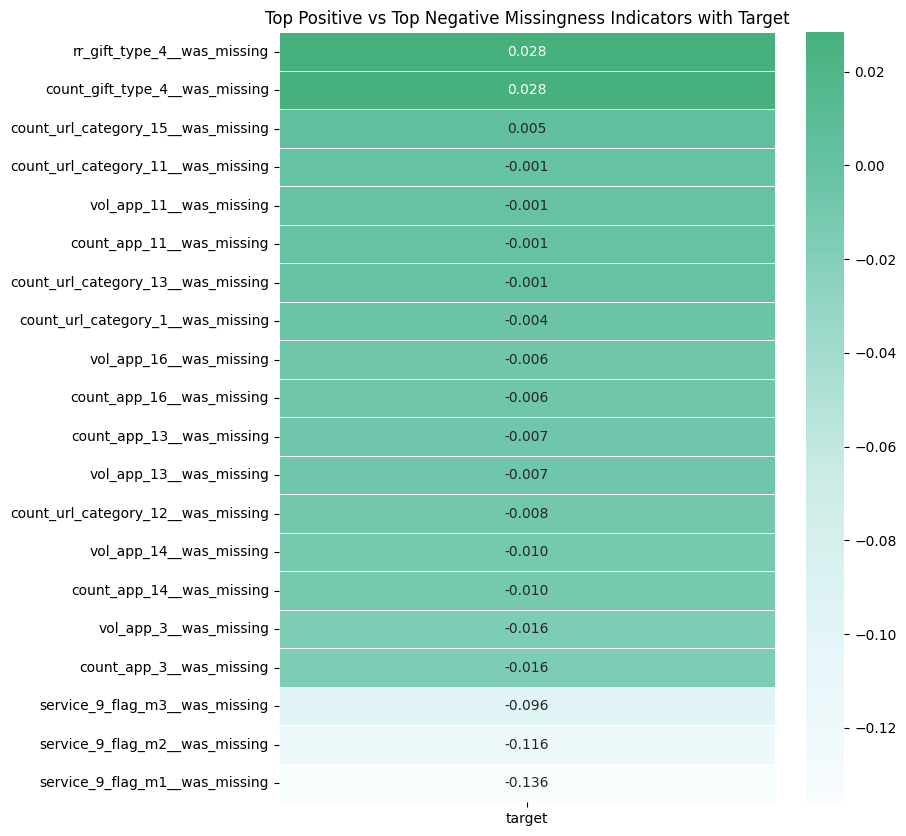

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
top_positive_missing = miss_corr[1:11]  # Skip the first one which is target itself
top_negative_missing = miss_corr.tail(10)

# Combining variables for a graph
top_features = pd.concat([top_positive_missing, top_negative_missing])
corr_matrix_to_plot = top_features.to_frame(name='target')

# Building a graph
plt.figure(figsize=(8, 10))
sns.heatmap(
    corr_matrix_to_plot,
    annot=True,
    cmap='BuGn',
    center=0,
    fmt=".3f",             # 3 decimal places for accuracy
    linewidths=0.5
)
plt.title("Top Positive vs Top Negative Missingness Indicators with Target")
plt.show()

#### Missingness Signal Interpretation

The most informative missingness indicators are from `service_9_flag_m*` features:

| Indicator | Pearson r with target |
|---|---|
| `service_9_flag_m1__was_missing` | -0.136 |
| `service_9_flag_m2__was_missing` | -0.116 |
| `service_9_flag_m3__was_missing` | -0.096 |

**Interpretation:** Users who *have* `service_9` active (i.e., the flag is NOT missing)
are more likely to subscribe to Music. The absence of this service is a negative signal.

These three indicators are retained as **engineered features** in the final dataset.
All others had |r| ≤ 0.02 and were dropped as noise.

### 7. Group-Based Imputation Rules

Imputation rules depend on feature meaning (group from the dictionary):

- Activity / usage metrics (cost/count/duration/volume, campaigns, interests, etc.) → `0`
- User profile-like continuous metrics (e.g., balance/inactive days) → `median`
- Device-related categorical codes → `mode`
- Unmapped features → conservative fallback (`0` for activity-like, otherwise `median`)

In [7]:
def norm_group(s: str) -> str:
    return " ".join(str(s).strip().lower().split())

# Normalize dictionary group values once
feature_to_group_norm = {k: norm_group(v) for k, v in feature_to_group.items()}

# Define 13 groups (normalized)
G_DEVICE  = norm_group("Device Characteristics")
G_GENERAL = norm_group("General Characteristics")
G_UACT    = norm_group("User Activity Features")
G_DYN     = norm_group("Features in Dynamics (Previous month, 2 Months ago, 3 Month Ago with prfx m1,m2,m3)")
G_COSTS   = norm_group("All Costs")
G_RECH    = norm_group("Recharg. Statistics")
G_VCOST   = norm_group("Voice Costs")
G_VDUR    = norm_group("Voice Duration")
G_NET     = norm_group("Network Actions Stats")
G_ESS     = norm_group("Other Essential Features")
G_SMS     = norm_group("SMS from Services")
G_INTER   = norm_group("Interests Data")
G_CAMP    = norm_group("Previous Campaigns Results")

zero_groups   = {G_COSTS, G_RECH, G_VCOST, G_VDUR, G_NET, G_SMS, G_INTER, G_CAMP}
median_groups = {G_UACT}

def fill_mode(series: pd.Series):
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) else 0

report = []

for col in df.columns:
    if col == "target":
        continue
    if df[col].isna().sum() == 0:
        continue

    # Determine group (exact or via base name)
    grp = None
    if col in feature_to_group_norm:
        grp = feature_to_group_norm[col]
    else:
        base = strip_m_suffix(col)
        if base in feature_to_group_norm:
            grp = feature_to_group_norm[base]

    n_missing = int(df[col].isna().sum())

    if grp in zero_groups:
        df[col] = df[col].fillna(0)
        report.append((col, grp, n_missing, "fillna(0)"))

    elif grp in median_groups:
        df[col] = df[col].fillna(df[col].median())
        report.append((col, grp, n_missing, "median"))

    elif grp == G_DEVICE:
        if col.lower() == "sim_count":
            df[col] = df[col].fillna(df[col].median())
            report.append((col, grp, n_missing, "median"))
        else:
            df[col] = df[col].fillna(fill_mode(df[col]))
            report.append((col, grp, n_missing, "mode"))

    elif grp == G_GENERAL:
        cl = col.lower()
        if "flag" in cl or "count" in cl:
            df[col] = df[col].fillna(0)
            report.append((col, grp, n_missing, "fillna(0)"))
        elif cl in ["lt", "days_exp"]:   # <-- FIX
            df[col] = df[col].fillna(df[col].median())
            report.append((col, grp, n_missing, "median"))
        else:
            df[col] = df[col].fillna(df[col].median())
            report.append((col, grp, n_missing, "median(fallback)"))

    elif grp == G_DYN:
        cl = col.lower()
        if any(k in cl for k in ["count", "cost", "dur", "flag", "vol", "sum", "paym", "sms", "voice", "data", "content"]):
            df[col] = df[col].fillna(0)
            report.append((col, grp, n_missing, "fillna(0)"))
        else:
            df[col] = df[col].fillna(df[col].median())
            report.append((col, grp, n_missing, "median"))

    elif grp == G_ESS:
        cl = col.lower()
        if cl.startswith("income"):
            df[col] = df[col].fillna(df[col].median())
            report.append((col, grp, n_missing, "median(income)"))
        elif any(k in cl for k in ["count", "cost", "flag", "content", "service", "data_type", "vol"]):
            df[col] = df[col].fillna(0)
            report.append((col, grp, n_missing, "fillna(0)"))
        else:
            df[col] = df[col].fillna(df[col].median())
            report.append((col, grp, n_missing, "median(fallback)"))

    else:
        cl = col.lower()
        if any(k in cl for k in ["count", "cost", "dur", "flag", "vol", "sms", "voice", "paym", "content", "data_type"]):
            df[col] = df[col].fillna(0)
            report.append((col, "unmapped", n_missing, "fillna(0) fallback"))
        else:
            df[col] = df[col].fillna(df[col].median())
            report.append((col, "unmapped", n_missing, "median fallback"))

rep_df = pd.DataFrame(report, columns=["feature", "group", "missing_filled", "method"])
print("\nImputation methods used:")
print(rep_df["method"].value_counts())


Imputation methods used:
method
fillna(0)         441
median              5
median(income)      3
Name: count, dtype: int64


#### Imputation Summary and Rationale

**Group-based imputation rules applied:**

| Group | Strategy | Rationale |
|---|---|---|
| Costs, Recharge, Voice, SMS, Interests, Campaigns, Network | Fill → **0** | Missing = no activity |
| User Activity Features (balance, payments, inactivity) | Fill → **median** | Continuous behavior metrics |
| Device Characteristics — `sim_count` | Fill → **median** | 0 SIMs is unrealistic |
| Device Characteristics — other | Fill → **mode** | Categorical, most common device |
| General — flags/counts | Fill → **0** | Absence of service |
| General — continuous (`lt`, `days_exp`) | Fill → **median** | Continuous tenure metrics |
| Dynamic features (`_m1/_m2/_m3`) | Fill → **0** or **median** based on name pattern | Inherit base feature logic |

### 8. Imputation Report (Samples)

We keep a small report of how missing values were filled.

In [8]:
display(rep_df.head(20))

,feature,group,missing_filled,method
0,sim_count,device characteristics,699,median
1,days_exp,general characteristics,7,median
2,service_1_flag,general characteristics,7,fillna(0)
3,service_1_count,general characteristics,7,fillna(0)
4,service_2_flag,general characteristics,7,fillna(0)
5,service_3_flag,general characteristics,7,fillna(0)
6,balance_sum,user activity features,7,median
7,paym_last_days,user activity features,829,median
8,inact_days_count,user activity features,7,median
9,count_sms_source_1,sms from services,7934,fillna(0)


#### Imputation Report (Samples)

The table above presents a sample of features with missing values and the applied imputation strategy.

Observations:

* Device Characteristics

  * `sim_count` was imputed using the median, as zero would be unrealistic.

* General Characteristics

  * Binary flags (`service_1_flag`, `service_2_flag`, etc.) were imputed with 0, assuming absence of the service.

  * Continuous variables like `days_exp` were imputed with the median to preserve distribution stability.

* User Activity Features

  * Behavioral intensity metrics (`balance_sum`, `paym_last_days`, `inact_days_count`) were imputed using the median, as they represent continuous client behavior rather than event counts.

* SMS from Services

All count-based features were filled with 0, since missing values indicate no recorded activity.

This confirms that imputation decisions were applied consistently and in accordance with feature semantics rather than using a single global rule.

No missing values remain in the dataset after this stage.

### 9. Low-Information Features Removal

We remove features that carry **no useful information** for the model.

#### Removal criteria

| Criterion | Rule | Rationale |
|---|---|---|
| Constant feature | `nunique <= 1` | Zero variance — model can learn nothing |
| Quasi-constant feature | Top value share > 99.9% | Near-zero variance, likely noise |
| Feature not in dictionary (if applies) | `|r_target|` is negligible | No semantic meaning + no signal = no value |

#### Note on features absent from the feature dictionary

In this dataset, **all 459 features are mapped** to a semantic group (via direct match or `_m1/_m2/_m3` suffix stripping).
There are **0 unmapped features** — so no columns need to be dropped on this basis.

However, the general principle applied in this project:
> If a feature has no description in the dictionary **and** shows negligible correlation with the target (|r| < 0.01),
> it is considered a black-box feature with no interpretable meaning and no predictive signal — and should be removed.
> Features that are unknown but show meaningful correlation may still be worth keeping as unexplained signal.

In [9]:
# Constant columns
constant_cols = [c for c in df.columns if c != "target" and df[c].nunique(dropna=False) <= 1]
df = df.drop(columns=constant_cols)
print("Constant columns removed:", len(constant_cols))

# Quasi-constant columns
threshold = 0.999
quasi_constant_cols = []
for col in [c for c in df.columns if c != "target"]:
    top_share = df[col].value_counts(normalize=True, dropna=False).iloc[0]
    if top_share > threshold:
        quasi_constant_cols.append(col)

df = df.drop(columns=quasi_constant_cols)
print("Quasi-constant columns removed (>99.9% same):", len(quasi_constant_cols))

Constant columns removed: 15
Quasi-constant columns removed (>99.9% same): 20


After removing low-information features:

- **15 constant features** removed (`nunique == 1`, zero variance)
- **20 quasi-constant features** removed (top value share > 99.9%)

These features provide no predictive power and may destabilize models sensitive to near-zero-variance inputs.

> Removing them reduces dimensionality without any information loss.

### 10. Duplicate Check

We explicitly check and remove duplicate rows (if any).

In [10]:
dup_count = int(df.duplicated().sum())
print("Duplicate rows BEFORE drop:", dup_count)

if dup_count > 0:
    df = df.drop_duplicates().copy()

print("Duplicate rows AFTER drop:", int(df.duplicated().sum()))

Duplicate rows BEFORE drop: 0
Duplicate rows AFTER drop: 0


No duplicate rows were found in the dataset.

Each observation represents a unique customer profile, and no redundant records were removed.


### 11. Final Validation & Save

In [11]:
print('\n--- Final Validation ---')
print('Final shape:', df.shape)
print('Remaining NaNs:', int(df.isna().sum().sum()))
print('Columns with NaNs:', int((df.isna().sum() > 0).sum()))

# Report which __was_missing indicators are still in the dataset
kept_miss = [c for c in df.columns if c.endswith('__was_missing')]
print(f'\nEngineered missingness indicators kept: {len(kept_miss)}')
if kept_miss:
    print('  ', kept_miss)

# Save cleaned dataset
import os
out_path = '../data/processed/train_cleaned.csv'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
df.to_csv(out_path, index=False)
print(f'\nSaved cleaned dataset to: {out_path}')


--- Final Validation ---
Final shape: (70000, 430)
Remaining NaNs: 0
Columns with NaNs: 0

Engineered missingness indicators kept: 5
   ['count_gift_type_4__was_missing', 'rr_gift_type_4__was_missing', 'service_9_flag_m3__was_missing', 'service_9_flag_m1__was_missing', 'service_9_flag_m2__was_missing']

Saved cleaned dataset to: ../data/processed/train_cleaned.csv


#### Final Dataset Status

After applying group-based imputation and removing low-information features:

| Step | Change |
|---|---|
| Original shape | 70,000 × 461 |
| Drop `id` | –1 column |
| Drop constant columns | –15 columns |
| Drop quasi-constant columns | –20 columns |
| Add missingness indicators (kept signal) | +5 columns |
| **Final shape** | **70,000 × 430** |
| Missing values remaining | **0** |

The cleaned dataset is saved to `data/processed/train_cleaned.csv`.

> **Cleaned data contract:**
> - ✅ No NaNs
> - ✅ No constant or quasi-constant columns
> - ✅ No duplicate rows
> - ✅ All features mapped to semantic groups
> - ✅ `service_9_flag_m*__was_missing` and `*_gift_type_4__was_missing` retained as engineered features
> - ✅ `id` dropped (non-feature identifier)
> - ➡️ Class imbalance (7.6% positive) — will be addressed during model training (class weights / SMOTE)